In [1]:
# !pip install telonex
from telonex import get_dataframe, download

In [23]:
import os
from datetime import datetime, timedelta
import pandas as pd
from pathlib import Path
import pyarrow
import numpy as np
import matplotlib.pyplot as plt

In [3]:
mkt_df = pd.read_parquet("../datasets/polymarket_markets.parquet")

In [4]:
mkt_df.head(5)

,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
0,polymarket,0x467022bb219ee9b887ee30d71d2fcd7fe167103734f2...,lol-zena-ae2-2026-05-01-game-handicap-home-1pt5,437281,lol-zena-ae2-2026-05-01,LoL: Zena Esports vs Aeterna Esports (BO5) - L...,Game Handicap: AE (-1.5) vs Zena Esports (+1.5),This market refers to the LoL Lower bracket ro...,,Aeterna Esports,...,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-03,2026-05-01,2026-05-02
1,polymarket,0x71a16036517a496f27b394718884d023a595a48d5586...,fl1-pfc-sbr-2026-05-03-exact-score-4-2,398102,fl1-pfc-sbr-2026-05-03-exact-score,Paris FC vs. Stade Brestois 29 - Exact Score,Exact Score: Paris FC 4 - 2 Stade Brestois 29?,In the upcoming Ligue 1 game between Paris FC ...,,Yes,...,2026-04-20,2026-05-04,2026-04-20,2026-05-04,2026-04-20,2026-05-04,2026-04-20,2026-05-04,,
2,polymarket,0xf9b3d64289d23b9c0bc7d3228dff1348107450b388b5...,,,,,,,,,...,,,,,,,,,,
3,polymarket,0x448b030b6d1172302e2ac4879e3d006e0542dc90a8f8...,,,,,,,,,...,,,,,,,,,,
4,polymarket,0x85d4f800924b0eaa45a7a7447bf51f0caae8e1c979cb...,btc-updown-5m-1777033800,409754,btc-updown-5m-1777033800,"Bitcoin Up or Down - April 24, 8:30AM-8:35AM ET","Bitcoin Up or Down - April 24, 8:30AM-8:35AM ET","This market will resolve to ""Up"" if the Bitcoi...",,Up,...,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-23,2026-04-25,2026-04-24,2026-04-25


In [9]:
nba_tags = sorted({

    tag

    for tags in mkt_df["tags"].dropna()

    for tag in np.asarray(tags).ravel()

    if isinstance(tag, str) and "nba" in tag.lower()

})

nba_tags

['2026-nba-all-star',
 '2026-nba-all-star-game',
 '2026-nba-draft',
 '2026-nba-draft-lottery',
 '2026-nba-playoffs',
 '2026-nba-rising-stars',
 '2026-nba-western-conference-finals',
 '2026-wnba-playoffs',
 'all-nba',
 'claudia-sheinbaum',
 'coinbase',
 'donbas',
 'donbass',
 'nba',
 'nba-all-star',
 'nba-all-star-game',
 'nba-all-star-weekend',
 'nba-champion',
 'nba-championship',
 'nba-cup',
 'nba-draft',
 'nba-finals',
 'nba-playoffs',
 'nba-rising-stars',
 'wnba',
 'wnba-finals']

In [5]:
filtered_df = mkt_df[mkt_df["tags"].apply(lambda x: "2026-nba-playoffs" in x)]
filtered_df

,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
1960,polymarket,0xbbf3418f51b370c98f1d043cfcad73f64ac7b1a8ffc5...,will-og-anunoby-lead-the-2026-nba-finals-in-3-...,555194,nba-finals-total-3pm-leader,NBA Finals: Total 3PM Leader,Will OG Anunoby lead the 2026 NBA Finals in 3-...,This market will resolve in favor of the playe...,,Yes,...,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-07
2014,polymarket,0xb374ade62efdf2d6914d6fa1d0078eb2f620b6fe2847...,will-player-r-win-the-2026-western-conference-...,375802,nba-playoffs-western-conference-finals-mvp,NBA Playoffs: Western Conference Finals MVP,Will Player R win the 2026 Western Conference ...,This market will resolve to the player who win...,,Yes,...,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-17,2026-06-01,2026-05-19,2026-05-28
6265,polymarket,0xedc4ea0a80f3fc6324b95a9d64251381b807255489d9...,will-carter-bryant-lead-the-2026-nba-finals-in...,560508,nba-finals-total-points-leader-20260603024024282,NBA Finals: Total Points Leader,Will Carter Bryant lead the 2026 NBA Finals in...,This market will resolve in favor of the playe...,,Yes,...,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08,2026-06-05,2026-06-08
10870,polymarket,0x9b6eaeeda644e1cb4d0345d9b46a235c13f324b6562d...,will-player-e-lead-the-2026-nba-finals-in-tota...,560435,nba-finals-total-rebounds-leader-2026060302402...,NBA Finals: Total Rebounds Leader,Will Player E lead the 2026 NBA Finals in tota...,This market will resolve in favor of the playe...,,Yes,...,,,,,,,,,,
12630,polymarket,0x298157e618b5729dafd742eec9b21e040a13da0bb09f...,will-the-utah-jazz-win-the-2026-nba-finals,27830,2026-nba-champion,2026 NBA Champion,Will the Utah Jazz win the 2026 NBA Finals?,This market will resolve to “Yes” if the Utah ...,,Yes,...,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-10-11,2026-03-20,2025-06-29,2026-03-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578159,polymarket,0x0f439cf8fc09856a95dda7e0f2a4299044cb7e5abae8...,will-tim-duncan-attend-any-game-at-the-2026-nb...,551757,nba-playoffs-who-will-attend-the-nba-finals,NBA Playoffs: Who will attend the NBA Finals?,Will Tim Duncan attend any game at the 2026 NB...,"The 2026 NBA Finals are scheduled for June 3, ...",,Yes,...,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06,2026-06-02,2026-06-06
1579817,polymarket,0x8afcf7b40b763d9ae80559b6b973023bdb32e9d6ef55...,will-player-ak-win-the-2026-eastern-conference...,375768,nba-playoffs-eastern-conference-finals-mvp,NBA Playoffs: Eastern Conference Finals MVP,Will Player AK win the 2026 Eastern Conference...,This market will resolve to the player who win...,,Yes,...,,,,,,,,,,
1580449,polymarket,0x508f1fcfc89f9337c6189181991590521a965a558ea9...,will-there-be-a-different-number-of-games-play...,556308,nba-finals-exact-series-length,NBA Finals: Exact Series Length,Will there be a different number of games play...,This market will resolve according to the numb...,,Yes,...,,,,,,,,,,
1582258,polymarket,0x414ca07f8900b427b5941f50fcb04563a65402dff606...,will-knicks-win-the-2026-nba-finals-4-2-be-the...,556284,nba-playoffs-finals-exact-outcome,NBA Playoffs: Finals Exact Outcome,Will Knicks win the 2026 NBA Finals 4-2 be the...,This market will resolve according to the exac...,,Yes,...,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-03,2026-06-08,2026-06-04,2026-06-08


In [12]:
filtered_df[filtered_df["tags"].apply(lambda x: "lakers" in x)]


,exchange,market_id,slug,event_id,event_slug,event_title,question,description,category,outcome_0,...,quotes_from,quotes_to,book_snapshot_5_from,book_snapshot_5_to,book_snapshot_25_from,book_snapshot_25_to,book_snapshot_full_from,book_snapshot_full_to,onchain_fills_from,onchain_fills_to
70148,polymarket,0x0b7b858bcd484321e2d605e1baca78d4c05500dbd173...,nba-playoffs-thunder-vs-lakers-total-games-ou-...,441249,nba-playoffs-thunder-vs-lakers-total-games-ou-...,NBA Playoffs: Thunder vs. Lakers Total Games O...,NBA Playoffs: Thunder vs. Lakers Total Games O...,This market will resolve to “Over” if more tha...,,Over 5.5,...,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13
100267,polymarket,0x6a251873cf1b1960d1b666ed0e7e2578ccc94b481d10...,nba-playoffs-rockets-vs-lakers-total-games-ou-...,375915,nba-playoffs-rockets-vs-lakers-total-games-ou-...,NBA Playoffs: Rockets vs. Lakers Total Games O...,NBA Playoffs: Rockets vs. Lakers Total Games O...,This market will resolve to “Over” if more tha...,,Over 5.5,...,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-13,2026-05-03,2026-04-14,2026-05-03
1103209,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,441257,nba-playoffs-who-will-win-series-thunder-vs-la...,NBA Playoffs: Who Will Win Series? - Thunder v...,NBA Playoffs: Who Will Win Series? - Thunder v...,This market will resolve to “Thunder” if the O...,,Thunder,...,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13,2026-05-02,2026-05-13
1513732,polymarket,0x13b1bfb4d3d001814cc7c7dcecbd2de54befc1a33dc1...,nba-playoffs-who-will-win-series-lakers-vs-roc...,388968,nba-playoffs-who-will-win-series-lakers-vs-roc...,NBA Playoffs: Who Will Win Series? - Lakers vs...,NBA Playoffs: Who Will Win Series? - Lakers vs...,This market will resolve to “Lakers” if the Lo...,,Lakers,...,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03,2026-04-17,2026-05-03


In [13]:
df = pd.read_parquet("/Users/zoujing/Desktop/Stanford/Spring 2026/Trading/final_proj/MS&E242_final/data/raw/book_snapshot_25/nba_playoffs_who_will_win_series_thunder_vs_lakers__Thunder/polymarket_book_snapshot_25_2026-05-02_nba-playoffs-who-will-win-series-thunder-vs-lakers_Thunder.parquet")

In [15]:
df.head(5)

,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bid_price_0,bid_size_0,bid_price_1,...,ask_price_20,ask_size_20,ask_price_21,ask_size_21,ask_price_22,ask_size_22,ask_price_23,ask_size_23,ask_price_24,ask_size_24
0,1777728715639000,1777728715704122,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,100,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1777728715982000,1777728715991501,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,130,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1777728728632000,1777728728694718,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,693,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1777728729174000,1777728729181174,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.01,693,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1777728790003000,1777728790011754,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,0.02,200,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
N_LEVELS = 10
RAW_DIR = Path("../data/raw")
CHANNEL = "book_snapshot_25"
def load_clean_book(slug=None, outcome=None, n_levels=N_LEVELS, raw_df=None):
    """Load the top n_levels of a contract's order book; return a time-sorted, numeric
    DataFrame that includes a mid-price column.

    Missing-level fill rules (so the OF three-case test is numerically self-consistent):
      missing bid price -> 0.0 (probability lower bound) ; missing ask price -> 1.0 (upper bound)
      any missing size  -> 0.0 (no resting order)
    mid is computed from the raw best level; rows with a missing best bid/ask are dropped
    (mid is undefined there).
    """
    cols = ["timestamp_us"]
    for i in range(n_levels):
        cols += [f"bid_price_{i}", f"bid_size_{i}", f"ask_price_{i}", f"ask_size_{i}"]
    
    if raw_df is None:
        folder = RAW_DIR / CHANNEL / f"{slug.replace('-', '_')}__{outcome}"
        files = sorted(folder.glob("*.parquet"))
        if not files:
            raise FileNotFoundError(folder)
        df = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
    else:
        df = raw_df.copy()
        
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)
    # Remove duplicate timestamps: keep the last book state within each microsecond.
    # ~7–10% of rows are exact or near-simultaneous duplicates emitted by Telonex.
    n_before = len(df)
    df = df.drop_duplicates(subset=["ts"], keep="last").reset_index(drop=True)
    if len(df) < n_before:
        pass  # duplicates silently dropped; caller can log if needed

    # Coerce to numeric (Telonex stores price/size as strings; empty levels are NaN).
    price_size_cols = [c for c in cols if c != "timestamp_us"]
    for c in price_size_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop rows where best level is missing OR the book is inverted (bid >= ask).
    # Inverted rows (~0.03–0.63% per market) are invalid LOB states from Telonex.
    df = df.dropna(subset=["bid_price_0", "ask_price_0"]).reset_index(drop=True)
    df = df[df["bid_price_0"] < df["ask_price_0"]].reset_index(drop=True)
    df["mid"] = (df["bid_price_0"] + df["ask_price_0"]) / 2

    # Fill deeper-level missing values.
    for i in range(n_levels):
        df[f"bid_price_{i}"] = df[f"bid_price_{i}"].fillna(0.0)
        df[f"ask_price_{i}"] = df[f"ask_price_{i}"].fillna(1.0)
        df[f"bid_size_{i}"]  = df[f"bid_size_{i}"].fillna(0.0)
        df[f"ask_size_{i}"]  = df[f"ask_size_{i}"].fillna(0.0)
    return df


# Quick sanity check: load the first usable market.
clean_df = load_clean_book(slug="nba-playoffs-who-will-win-series-thunder-vs-lakers", 
                           outcome="Thunder", n_levels=10)
                           

In [22]:
clean_df

,timestamp_us,bid_price_0,bid_size_0,ask_price_0,ask_size_0,bid_price_1,bid_size_1,ask_price_1,ask_size_1,bid_price_2,...,bid_price_8,bid_size_8,ask_price_8,ask_size_8,bid_price_9,bid_size_9,ask_price_9,ask_size_9,ts,mid
0,1777728715639000,0.010,100.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:31:55.639000+00:00,0.5000
1,1777728715982000,0.010,130.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:31:55.982000+00:00,0.5000
2,1777728728632000,0.010,693.0,0.990,100.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:32:08.632000+00:00,0.5000
3,1777728729174000,0.010,693.0,0.990,663.0,0.000,0.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:32:09.174000+00:00,0.5000
4,1777728790003000,0.020,200.0,0.990,663.0,0.010,693.0,1.0,0.0,0.000,...,0.000,0.00,1.0,0.0,0.000,0.00,1.0,0.0,2026-05-02 13:33:10.003000+00:00,0.5050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45371,1778563068319000,0.992,500.0,0.999,14.0,0.988,40.0,1.0,0.0,0.987,...,0.950,200.00,1.0,0.0,0.941,54.99,1.0,0.0,2026-05-12 05:17:48.319000+00:00,0.9955
45372,1778563281927000,0.992,500.0,0.999,1000.0,0.988,40.0,1.0,0.0,0.987,...,0.941,54.99,1.0,0.0,0.940,31.12,1.0,0.0,2026-05-12 05:21:21.927000+00:00,0.9955
45373,1778563281972000,0.992,500.0,0.999,995.0,0.988,40.0,1.0,0.0,0.987,...,0.941,54.99,1.0,0.0,0.940,31.12,1.0,0.0,2026-05-12 05:21:21.972000+00:00,0.9955
45374,1778563283965000,0.992,500.0,0.999,995.0,0.988,40.0,1.0,0.0,0.987,...,0.940,31.12,1.0,0.0,0.931,2125.00,1.0,0.0,2026-05-12 05:21:23.965000+00:00,0.9955


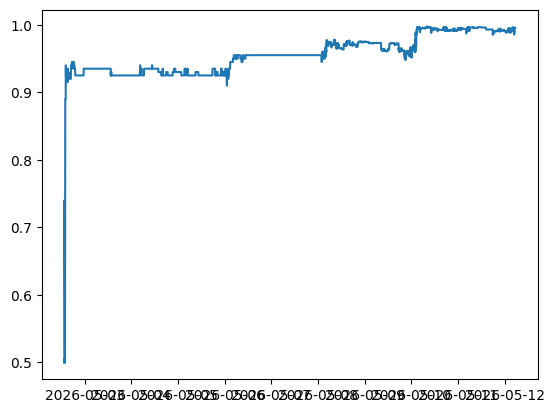

In [29]:
# filtered_clean_df = clean_df[(clean_df["ts"] >= "2026-05-09") & (clean_df["ts"] <= "2026-05-10")]
plt.plot(clean_df["ts"], clean_df["mid"])

In [27]:
filtered_clean_df

,timestamp_us,bid_price_0,bid_size_0,ask_price_0,ask_size_0,bid_price_1,bid_size_1,ask_price_1,ask_size_1,bid_price_2,...,bid_price_8,bid_size_8,ask_price_8,ask_size_8,bid_price_9,bid_size_9,ask_price_9,ask_size_9,ts,mid
21755,1778284978776000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:02:58.776000+00:00,0.9745
21756,1778284979220000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:02:59.220000+00:00,0.9745
21757,1778285118000000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.990,172.82,0.951,500.0,0.998,285.80,2026-05-09 00:05:18+00:00,0.9745
21758,1778285118034000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.990,172.82,0.951,500.0,0.998,285.80,2026-05-09 00:05:18.034000+00:00,0.9745
21759,1778285118230000,0.973,23.98,0.976,497.95,0.971,507.95,0.977,1590.3,0.970,...,0.953,6.38,0.989,60000.00,0.951,500.0,0.990,172.82,2026-05-09 00:05:18.230000+00:00,0.9745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26400,1778370777455000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:52:57.455000+00:00,0.9665
26401,1778370930441000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:55:30.441000+00:00,0.9665
26402,1778371037436000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:57:17.436000+00:00,0.9665
26403,1778371057227000,0.963,3.25,0.970,66.46,0.962,10.40,0.972,150.0,0.961,...,0.940,6873.30,0.987,10.04,0.931,1000.0,0.988,58.33,2026-05-09 23:57:37.227000+00:00,0.9665


In [31]:
CHANNEL

'book_snapshot_25'

In [46]:
API_KEY  = "tlx_fdc7cb68070057d89b1c6986e4702649"
EXCHANGE = "polymarket"
CHANNEL = "book_snapshot_full"
slug = "nba-playoffs-who-will-win-series-thunder-vs-lakers"
outcome = "Thunder"
from_date = datetime(2026, 5, 7)
to_date = datetime(2026, 5, 7)

full_data = get_dataframe(
            api_key=API_KEY,
            exchange=EXCHANGE,
            channel=CHANNEL,
            slug=slug,
            outcome=outcome,
            from_date="2026-05-07",  # inclusive
            to_date="2026-05-09",   # +1 day to make the range inclusive
            verbose=True,
)

In [47]:
clean_data = full_data.copy()
clean_data['dt_utc'] = clean_data['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))
clean_data["dt_et"] = (

    pd.to_datetime(clean_data["dt_utc"], utc=True)

      .dt.tz_convert("America/New_York")

)
clean_data

/var/folders/nv/vxh9y3k11_dfzz7jl3bwkpyc0000gn/T/ipykernel_91204/4208552610.py:2: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  clean_data['dt_utc'] = clean_data['timestamp_us'].apply(lambda x: datetime.utcfromtimestamp(x / 1e6))


,timestamp_us,local_timestamp_us,exchange,market_id,slug,asset_id,outcome,bids,asks,dt_utc,dt_et
0,1778112162143000,1778112162151172,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.95', 'size': '7919.77'}, {'price...","[{'price': '0.96', 'size': '17252.18'}, {'pric...",2026-05-07 00:02:42.143,2026-05-06 20:02:42.143000-04:00
1,1778112162143000,1778112162151186,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.95', 'size': '7919.77'}, {'price...","[{'price': '0.96', 'size': '17252.18'}, {'pric...",2026-05-07 00:02:42.143,2026-05-06 20:02:42.143000-04:00
2,1778112162539000,1778112162546060,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.95', 'size': '7919.77'}, {'price...","[{'price': '0.96', 'size': '17252.18'}, {'pric...",2026-05-07 00:02:42.539,2026-05-06 20:02:42.539000-04:00
3,1778112162541000,1778112162549695,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.95', 'size': '7919.77'}, {'price...","[{'price': '0.96', 'size': '17252.18'}, {'pric...",2026-05-07 00:02:42.541,2026-05-06 20:02:42.541000-04:00
4,1778112439429000,1778112439438388,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.95', 'size': '7919.77'}, {'price...","[{'price': '0.96', 'size': '17252.18'}, {'pric...",2026-05-07 00:07:19.429,2026-05-06 20:07:19.429000-04:00
...,...,...,...,...,...,...,...,...,...,...,...
7774,1778284290145000,1778284290154441,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.973', 'size': '23.98'}, {'price'...","[{'price': '0.976', 'size': '497.95'}, {'price...",2026-05-08 23:51:30.145,2026-05-08 19:51:30.145000-04:00
7775,1778284563901000,1778284563924150,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.973', 'size': '23.98'}, {'price'...","[{'price': '0.976', 'size': '497.95'}, {'price...",2026-05-08 23:56:03.901,2026-05-08 19:56:03.901000-04:00
7776,1778284564626000,1778284564667032,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.973', 'size': '23.98'}, {'price'...","[{'price': '0.976', 'size': '497.95'}, {'price...",2026-05-08 23:56:04.626,2026-05-08 19:56:04.626000-04:00
7777,1778284698284000,1778284698292441,polymarket,0x1c0f817540f7834d109a903493de743fe8ef695ac1e4...,nba-playoffs-who-will-win-series-thunder-vs-la...,5470445245988189577771753238190557635105115431...,Thunder,"[{'price': '0.973', 'size': '23.98'}, {'price'...","[{'price': '0.976', 'size': '497.95'}, {'price...",2026-05-08 23:58:18.284,2026-05-08 19:58:18.284000-04:00


In [ ]:
def load_clean_book_from_df(raw_df, n_levels=N_LEVELS):
    """Clean a raw Telonex *full* order book (book_snapshot_full) and add a mid-price.

    Unlike book_snapshot_25 (flat bid_price_i / ask_price_i columns), the full book
    stores each side as a nested list of {'price', 'size'} dicts, best level first
    (bids descending in price, asks ascending). We flatten the top n_levels into the
    same flat layout the rest of the pipeline expects, then compute mid.

    Missing-level fill rules (so the OF three-case test is numerically self-consistent):
      missing bid price -> 0.0 (probability lower bound) ; missing ask price -> 1.0 (upper bound)
      any missing size  -> 0.0 (no resting order)
    mid is computed from the best level; rows with no bid or no ask (mid undefined) are dropped.
    """
    df = raw_df.copy()
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)

    # Remove duplicate timestamps: keep the last book state within each microsecond.
    n_before = len(df)
    df = df.drop_duplicates(subset=["ts"], keep="last").reset_index(drop=True)
    if len(df) < n_before:
        print(f"Dropped {n_before - len(df)} duplicate rows.")

    # Flatten the nested bids/asks lists into flat per-level columns. Levels beyond the
    # book's actual depth (or a missing/empty side) come out as NaN.
    def _level(book, i, key):
        if isinstance(book, (list, np.ndarray)) and i < len(book):
            return float(book[i][key])
        return np.nan

    for i in range(n_levels):
        df[f"bid_price_{i}"] = df["bids"].map(lambda b, i=i: _level(b, i, "price"))
        df[f"bid_size_{i}"]  = df["bids"].map(lambda b, i=i: _level(b, i, "size"))
        df[f"ask_price_{i}"] = df["asks"].map(lambda a, i=i: _level(a, i, "price"))
        df[f"ask_size_{i}"]  = df["asks"].map(lambda a, i=i: _level(a, i, "size"))

    # Drop rows where best level is missing OR the book is inverted (bid >= ask).
    # Inverted rows are invalid LOB states from Telonex.
    df = df.dropna(subset=["bid_price_0", "ask_price_0"]).reset_index(drop=True)
    df = df[df["bid_price_0"] < df["ask_price_0"]].reset_index(drop=True)
    df["mid"] = (df["bid_price_0"] + df["ask_price_0"]) / 2

    # Fill deeper-level missing values.
    for i in range(n_levels):
        df[f"bid_price_{i}"] = df[f"bid_price_{i}"].fillna(0.0)
        df[f"ask_price_{i}"] = df[f"ask_price_{i}"].fillna(1.0)
        df[f"bid_size_{i}"]  = df[f"bid_size_{i}"].fillna(0.0)
        df[f"ask_size_{i}"]  = df[f"ask_size_{i}"].fillna(0.0)
    return df


In [ ]:
df_2 = load_clean_book_from_df(full_data, n_levels=10)
df_2[["ts", "bid_price_0", "ask_price_0", "mid"]].head()